# Tujuan, Hipotesis, dan Data

1. Tujuan:
* Mencari apakah lama durasi visual novel (X) mempengaruhi kepuasan atau rating (Y)
* Mencari arah dan besarnya pengaruh tersebut

2. Hipotesis:
* H0 = Tidak ada pengaruh antara durasi dengan rating
* H1 = Ada pengaruh antara durasi dengan rating

3. Data:
* Data didapatkan dari Query VNDB (https://query.vndb.org/) dengan menggunakan query SQL

```sql
SELECT c_length, c_rating
FROM vn
WHERE (c_votecount > 50) AND (c_length IS NOT NULL) AND (c_rating IS NOT NULL)
```

# Import dan Load

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams
import seaborn as sns

import statsmodels.api as sm
import statsmodels.stats.diagnostic as diag
from statsmodels.stats.diagnostic import linear_rainbow, het_breuschpagan
from scipy.stats import shapiro, linregress

In [3]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [4]:
df_vn = pd.read_csv('vn-length-vs-rating.csv')

In [5]:
df_vn.sample(5)

,c_length,c_rating
426,2460,713
4071,135,589
1365,480,520
4121,960,753
2920,750,769


In [6]:
df_vn.shape

(4361, 2)

In [7]:
df_vn.describe()

,c_length,c_rating
count,4361.000000,4361.000000
mean,984.298326,689.076359
std,1014.178313,82.223157
min,2.000000,223.000000
25%,254.000000,645.000000
50%,660.000000,702.000000
75%,1440.000000,744.000000
max,13096.000000,923.000000


# Eksplorasi dan Visualisasi Awal

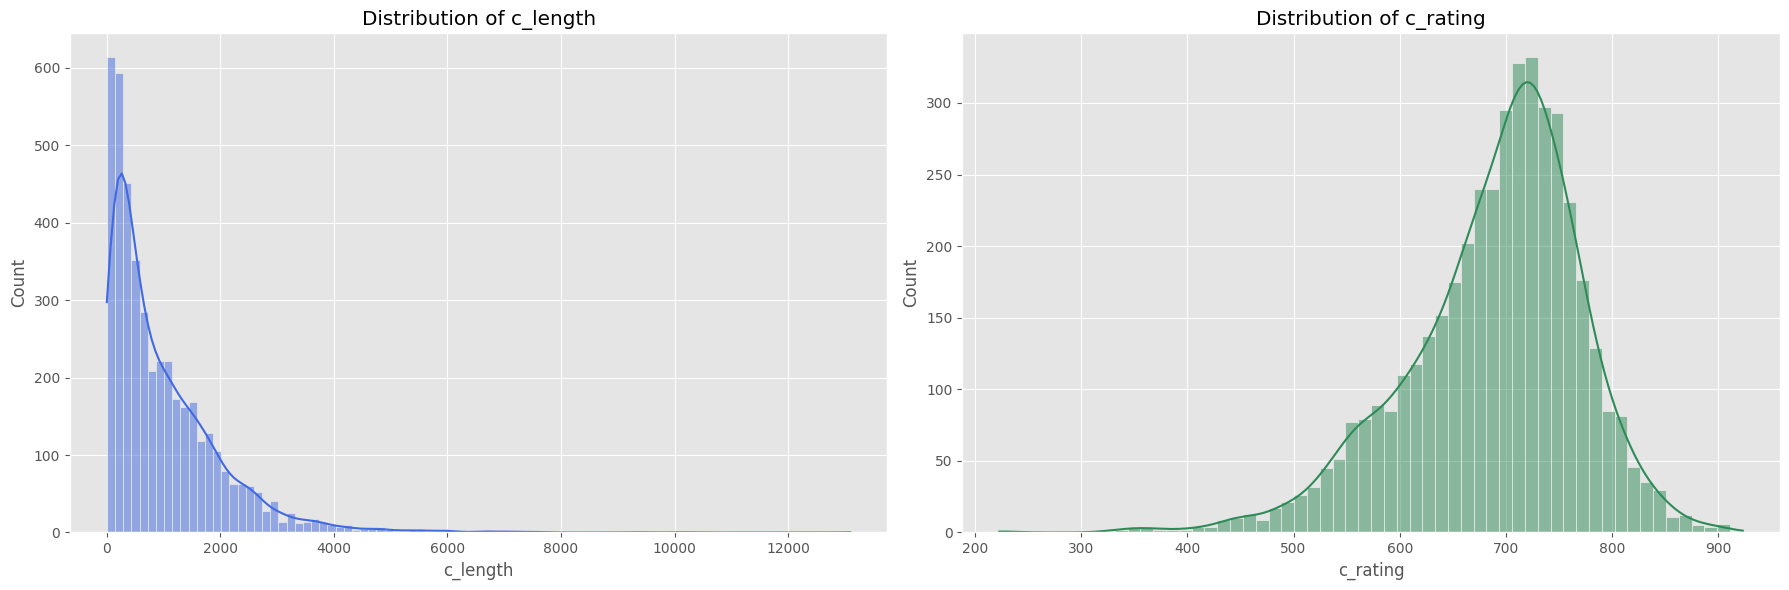

In [8]:
# Set up the figure for Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution for c_length
sns.histplot(df_vn['c_length'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of c_length')

# Distribution for c_rating
sns.histplot(df_vn['c_rating'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of c_rating')

plt.tight_layout()
plt.show()

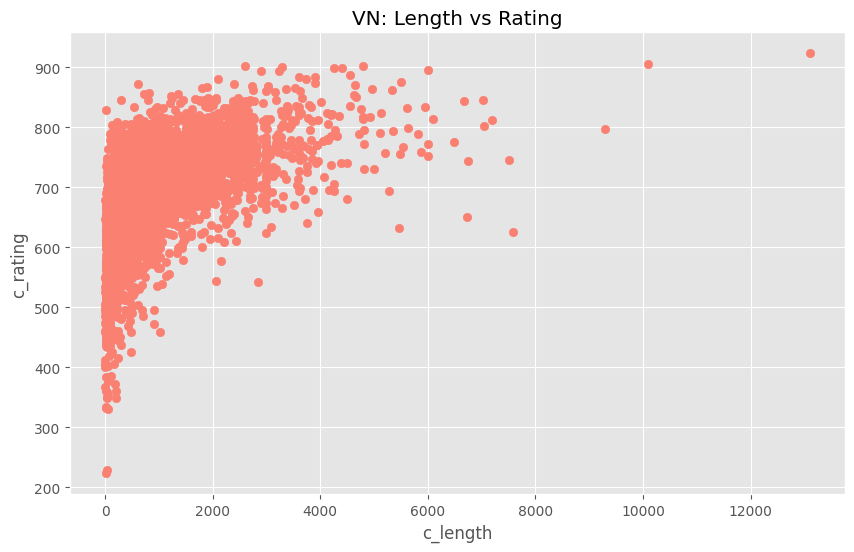

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_vn['c_length'], df_vn['c_rating'], color='salmon')
plt.xlabel(df_vn.columns[0])
plt.ylabel(df_vn.columns[1])
plt.title('VN: Length vs Rating')
plt.show()

* Data cenderung menumpuk di kiri (skew), kosong di bawah kanan (heteroskedastisitas) dan memiliki bentuk non linear. Ini perlu di-preprocessing terlebih dahulu.
* Jika seandainya visualisasi data scatter plot baik dan merupakan data "ideal" atau bersih, maka bisa skip preprocessing.

# Preprocessing (Prasyarat)

Mengubah (transformasi) data menjadi log pada X dan Y

In [10]:
df_transform = df_vn.copy()
df_transform['c_length'] = np.log1p(df_transform['c_length'])
df_transform['c_rating'] = np.log1p(df_transform['c_rating'])

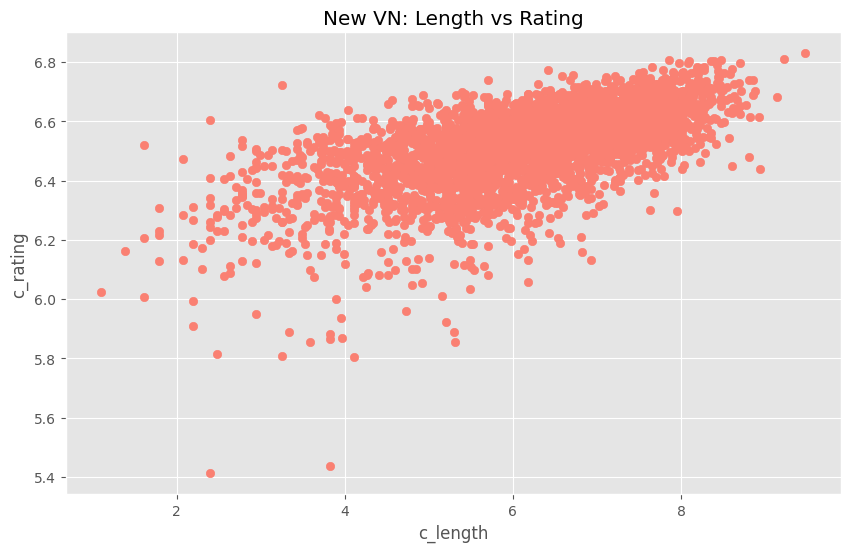

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df_transform['c_length'], df_transform['c_rating'], color='salmon')
plt.xlabel(df_transform.columns[0])
plt.ylabel(df_transform.columns[1])
plt.title('New VN: Length vs Rating')
plt.show()

Sudah terlihat lebih baik, sekarang bisa langsung ke langkah regresi.

Namun jika seandainya setelah transformasi masih "aneh", maka langsung pakai Robust Standard Error dari `Statsmodels` yaitu

```python
model = sm.OLS(df['Y'], X).fit(cov_type='HC3')
```

# Uji Asumsi Klasik Residual

## Regresi Linear untuk Residual

In [ ]:
X = df_transform['c_length']
Y = df_transform['c_rating']

Ini bisa juga dipakai untuk uji hipotesis awal. Tapi masih harus dilanjutkan menggunakan uji asumsi klasik untuk uji hipotesis final.

In [ ]:
X_sm = sm.add_constant(X)
model = sm.OLS(Y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               c_rating   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     2954.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:23:23   Log-Likelihood:                 3865.2
No. Observations:                4361   AIC:                            -7726.
Df Residuals:                    4359   BIC:                            -7714.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1150      0.008    787.569      0.0

* Kita bisa melihat pada P>|t| c_length memiliki nilai 0.000 yang berarti c_length (lama durasi VN) memang berpengaruh karena kurang dari 0.05.
* Nilai Koefisiennya adalah 0.0656 dan arahnya positif.
* Perlu diingat karena kita tadi menggunakan log, maka artinya bukan lagi "setiap kenaikan 1 nilai X, maka Y akan naik 0.0656", tapi "Setiap kenaikan 1% nilai X, maka Y akan naik 0.0656%".

## Uji Normalitas

Shapiro-Wilk Test: Stat=0.9334, p-value=0.0000


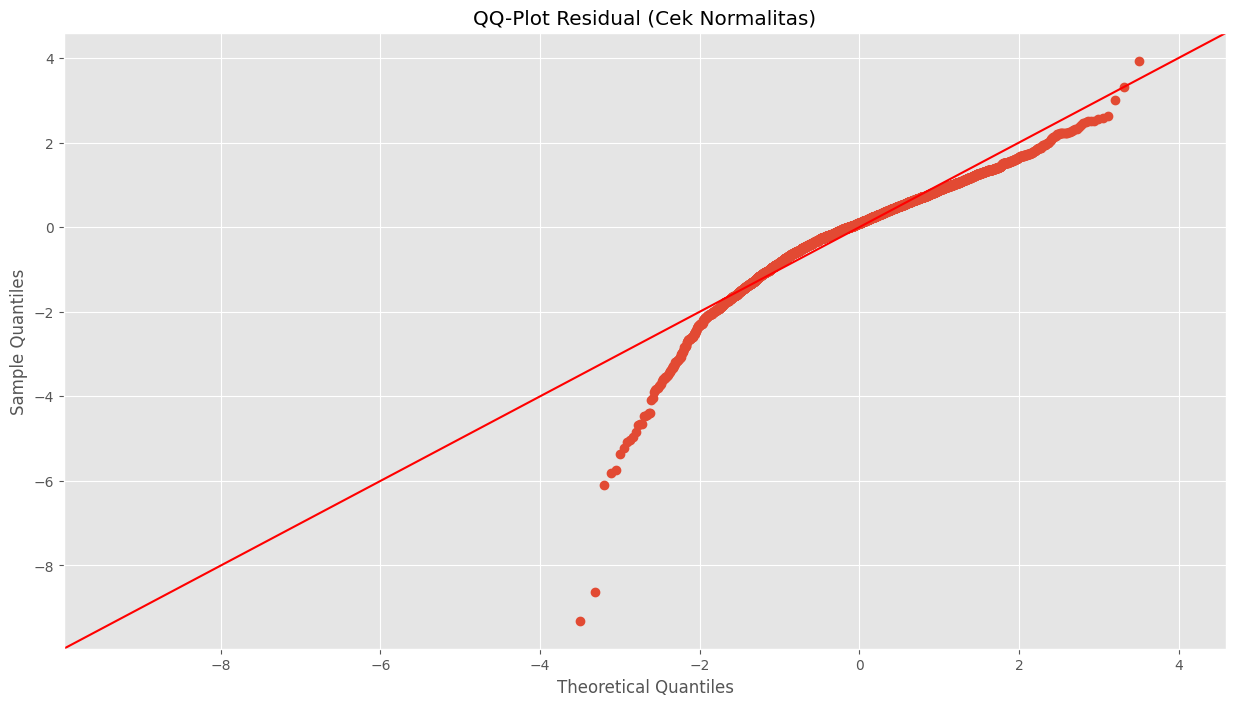

In [16]:
# Ambil nilai residual dari model
residual = model.resid

# 1. Uji Shapiro-Wilk
sw_stat, sw_p = shapiro(residual)
print(f"Shapiro-Wilk Test: Stat={sw_stat:.4f}, p-value={sw_p:.4f}")

# 2. Visualisasi QQ-Plot
sm.qqplot(residual, line='45', fit=True)
plt.title("QQ-Plot Residual (Cek Normalitas)")
plt.show()

# Interpretasi: Jika p-value > 0.05, residual Normal.

* Walaupun tidak normal sebenarnya tidak masalah, karena bisa pakai Central Limit Theorem. Apalagi untuk data sangat besar n>4000.
* Kalau seandainya datanya kecil (n < 30) dan tidak normal, maka tidak bisa pakai Regresi Linear dan harus menggunakan metode yang lain.

## Uji Heteroskedastis

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
# X adalah dataframe yang berisi konstanta dan variabel bebas
names = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test_result = het_breuschpagan(residual, model.model.exog)

print("Breusch-Pagan Test:")
print(dict(zip(names, test_result)))

# Interpretasi: Jika p-value > 0.05, maka Homoskedastis (Aman).

Breusch-Pagan Test:
{'Lagrange multiplier statistic': np.float64(200.35207288945887), 'p-value': np.float64(1.7498549195480698e-45), 'f-value': np.float64(209.9035296965535), 'f p-value': np.float64(1.7081519856810295e-46)}


Data bersifat Heteroskedastis, sehingga memerlukan HC3 (langkah berikutnya) pada uji hipotesis

## Uji Linearitas

In [18]:
# Rainbow test untuk linearitas
stat, p_value = diag.linear_rainbow(model)
print(f"Rainbow Test for Linearity: p-value={p_value:.4f}")

# Interpretasi: Jika p-value > 0.05, hubungan bersifat Linear.

Rainbow Test for Linearity: p-value=0.7175


* Uji Linearitas berhasil, berarti hubungan Linear.
* Jika seandainya uji ini gagal, maka beberapa yang bisa dilakukan antara lain:

1. Melakukan transformasi data bisa menggunakan Log, Sqrt(X), atau 1/X
2. Regresi Polinomial jika berbentuk polinomial, dengan menambah variabel baru X^2
3. Menggunakan Non-Parametrik
4. Dsb.

## Uji Multikolinearitas dan Autokorelasi

Untuk contoh kasus ini tidak ada.
* Multikolinearitas dipakai jika variabel X lebih dari 1, agar masing-masing variabel X tidak saling mempengaruhi atau tumpang tindih.
* Autokorelasi dipakai untuk data time-series, untuk memastikan bahwa tidak ada korelasi antar waktu atau data waktu sebelumnya tidak mempengaruhi waktu saat ini

# Uji Hipotesis: Regresi Linear

## Jika Seandainya Uji Heteroskedastis Lolos [Alternatif]

Bisa langsung dipakai saja `StatsModels` OLS Regresi Linear di awal. Atau kalau mau coba pakai `Scipy`

In [26]:
slope, intercept, r_value, p_value, std_err = linregress(df_transform['c_length'], df_transform['c_rating'])

print(f"Slope (Koefisien): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Koef. Korelasi (r): {r_value:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"Standard Error: {std_err:.4f}")

Slope (Koefisien): 0.0656
Intercept: 6.1150
P-value: 0.0000
Koef. Korelasi (r): 0.6356
R-squared: 0.4040
Standard Error: 0.0012


## Model Robust Standard Error (HC3) [Realita]

In [19]:
# Fit model dengan Robust Standard Errors (HC3)
model_robust = sm.OLS(Y, X_sm).fit(cov_type='HC3')

# Tampilkan hasil
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:               c_rating   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     1755.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          1.33e-322
Time:                        11:24:15   Log-Likelihood:                 3865.2
No. Observations:                4361   AIC:                            -7726.
Df Residuals:                    4359   BIC:                            -7714.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1150      0.011    573.368      0.0

Signifikansi, Koefisien, R-Squared tidak berubah dari model sebelumnya. Yang berubah hanya std err yang lebih tinggi di sini, yang mana model saat ini lebih bisa dipercaya

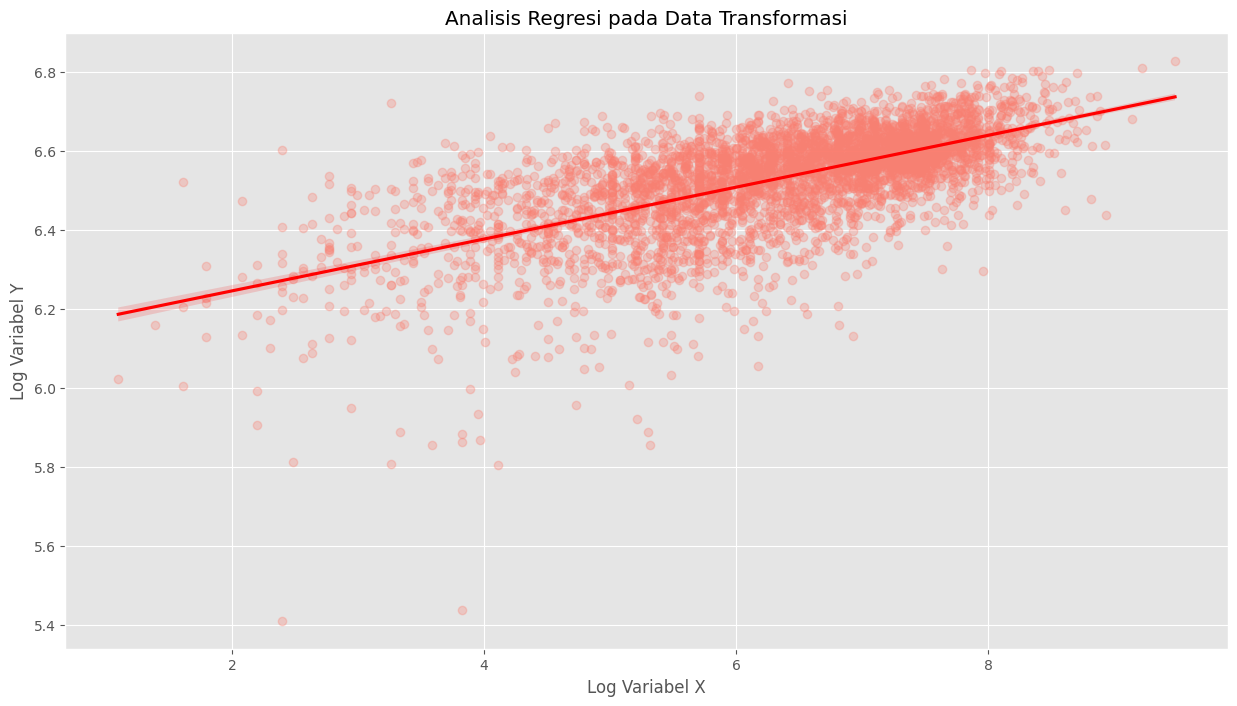

In [21]:
sns.regplot(x='c_length', y='c_rating', data=df_transform,
            scatter_kws={'alpha':0.3, 'color':'salmon'},
            line_kws={'color':'red'})
plt.title("Analisis Regresi pada Data Transformasi")
plt.xlabel("Log Variabel X")
plt.ylabel("Log Variabel Y")
plt.show()

# Jawaban

* Karena nilai signifikansi (p_value) sangat kecil atau kurang dari 0.05, maka kita menolak H0 (tidak ada pengaruh) dan menerima H1 (ada pengaruh).
* Hubungan antara kedua variabel adalah positif, yang berarti semakin lama durasi atau panjangnya VN, maka semakin tinggi ratingnya, dan begitu juga sebaliknya.
* Setiap kenaikan 1% durasi, maka rating akan naik 0.0656%.
* Nilai R-Squared adalah 0.404 yang berarti durasi visual novel dapat menjelaskan 40.4% variasi yang terjadi pada rating. Sisanya 59.6% dijelaskan oleh faktor lain di luar model ini.
* Meskipun hasil uji Breusch-Pagan menunjukkan adanya heteroskedastisitas dan sisaan (residual) tidak berdistribusi normal, model ini tetap valid karena diestimasi menggunakan Robust Standard Errors (HC3). Pendekatan ini mengoreksi bias pada varians sehingga nilai signifikansi (p-value) yang dihasilkan tetap akurat dan tidak menyesatkan